# Clean the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading CSV files and removing duplicates

Reads all dataset files and removes duplicate rows to ensure clean inputs.

In [2]:
df_Op = pd.read_csv('order_products.csv').drop_duplicates()
df_D = pd.read_csv('departments.csv').drop_duplicates()
df_A = pd.read_csv('aisles.csv').drop_duplicates()
df_P = pd.read_csv('products.csv').drop_duplicates()
df_O = pd.read_csv('orders.csv').drop_duplicates()

# Data overview

Displays the first rows of each table to verify structure and content.

In [3]:
print("order_products :")
display(df_Op.head())

print("departments :")
display(df_D.head())

print("aisles :")
display(df_A.head())

print("products :")
display(df_P.head())

print("orders :")
display(df_O.head())

order_products :


,order_id,product_id,add_to_cart_order,reordered
0,2,33120.0,1.0,1.0
1,2,28985.0,2.0,1.0
2,2,9327.0,3.0,0.0
3,2,45918.0,4.0,1.0
4,2,30035.0,5.0,0.0


departments :


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


aisles :


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


products :


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


orders :


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1.0,1.0,2.0,8.0,NaN,NaN
1,2398795,1.0,2.0,3.0,7.0,15.0,NaN
2,473747,1.0,3.0,3.0,12.0,21.0,NaN
3,2254736,1.0,4.0,4.0,7.0,29.0,NaN
4,431534,1.0,5.0,4.0,15.0,28.0,NaN


# Merging of product tables, sections and departments, and orders with products

Enriches each order by combining product details with aisle and department information to build a complete transactional dataset.

In [ ]:
products_full = df_P.merge(df_A, on="aisle_id", how="left")
products_full = products_full.merge(df_D, on="department_id", how="left")

orders_full = df_Op.merge(df_O, on="order_id", how="left")
orders_full = orders_full.merge(products_full, on="product_id", how="left")

# Selection of relevant columns

Keeps only the fields needed for analysis to simplify the dataset.

In [5]:
columns = [
    "order_id", "user_id", "order_number", "order_dow", "order_hour_of_day",
    "days_since_prior_order", "product_id", "product_name",
    "aisle", "department", "add_to_cart_order", "reordered"
]

dataset_final = orders_full[columns]

# Handling missing values

Replaces missing numeric values with zero to avoid errors in later processing.

In [6]:
numeric_columns = dataset_final.select_dtypes(include=['number']).columns

dataset_final[numeric_columns] = dataset_final[numeric_columns].fillna(0)

# Preview of the final dataset

Shows the cleaned and structured dataset for validation.

In [7]:
print(dataset_final.head())

   order_id   user_id  order_number  order_dow  order_hour_of_day  \
0         2  202279.0           5.0        9.0                8.0   
1         2  202279.0           5.0        9.0                8.0   
2         2  202279.0           5.0        9.0                8.0   
3         2  202279.0           5.0        9.0                8.0   
4         2  202279.0           5.0        9.0                8.0   

   days_since_prior_order  product_id           product_name  \
0                     0.0     33120.0     Organic Egg Whites   
1                     0.0     28985.0  Michigan Organic Kale   
2                     0.0      9327.0          Garlic Powder   
3                     0.0     45918.0         Coconut Butter   
4                     0.0     30035.0      Natural Sweetener   

                aisle  department  add_to_cart_order  reordered  
0                eggs  dairy eggs                1.0        1.0  
1    fresh vegetables     produce                2.0        1.0  
2 

# Export of the cleaned dataset

Saves the final dataset as a CSV file ready for analysis.

In [8]:
dataset_final.to_csv("cleaned_dataset_final.csv", index=False)

print("CSV created: cleaned_dataset_final.csv")

CSV created: cleaned_dataset_final.csv


# data Visualisation 

In [9]:
df = pd.read_csv('cleaned_dataset_final.csv')
df

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,product_name,aisle,department,add_to_cart_order,reordered
0,2,202279.0,5.0,9.0,8.0,0.0,33120.0,Organic Egg Whites,eggs,dairy eggs,1.0,1.0
1,2,202279.0,5.0,9.0,8.0,0.0,28985.0,Michigan Organic Kale,fresh vegetables,produce,2.0,1.0
2,2,202279.0,5.0,9.0,8.0,0.0,9327.0,Garlic Powder,spices seasonings,pantry,3.0,0.0
3,2,202279.0,5.0,9.0,8.0,0.0,45918.0,Coconut Butter,oils vinegars,pantry,4.0,1.0
4,2,202279.0,5.0,9.0,8.0,0.0,30035.0,Natural Sweetener,baking ingredients,pantry,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
13692881,2999999,100467.0,2.0,8.0,23.0,0.0,16797.0,Strawberries,fresh fruits,produce,4.0,1.0
13692882,2999999,100467.0,2.0,8.0,23.0,0.0,48812.0,Variety Pack,food storage,household,5.0,0.0
13692883,2999999,100467.0,2.0,8.0,23.0,0.0,4724.0,Broccoli Florettes,packaged produce,produce,6.0,1.0
13692884,2999999,100467.0,2.0,8.0,23.0,0.0,13176.0,Bag of Organic Bananas,fresh fruits,produce,7.0,1.0


### 1. When and how do customers usually order?
**Description:** This heatmap shows the density of orders based on day of week and time.

**Report & Business Insight:** It is very clearly observed that the volume of orders is at its maximum on days 0 and 1 (usually Sunday and Monday) between 10am and 4pm. On the other hand, the mid-week recorded a decline in activity. 

*Strategic action :* It is crucial to strengthen the capacity of servers and order preparation teams during these weekend peaks. To smooth the activity, the marketing team could send targeted promotions on Wednesdays to encourage ordering during the week.

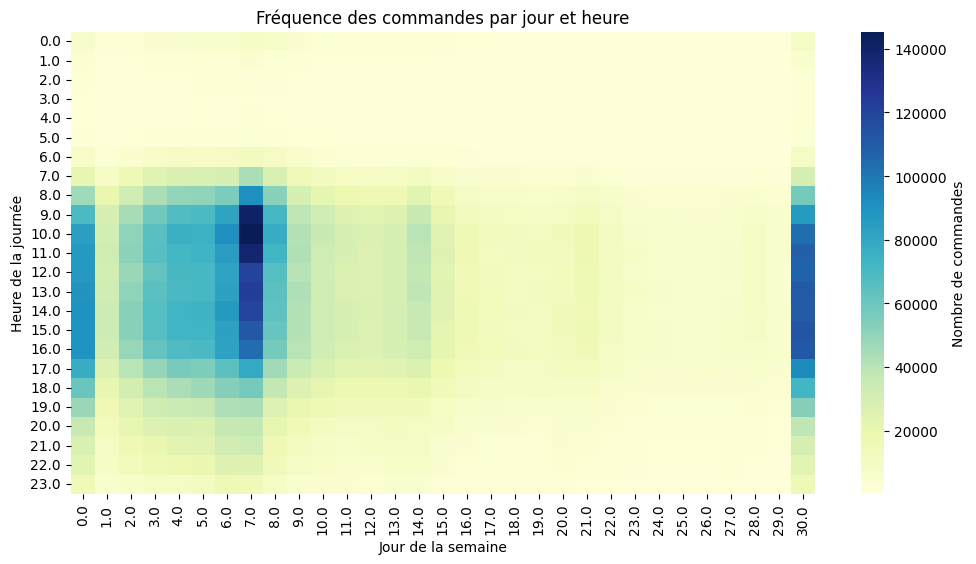

In [10]:
heatmap_data = df.groupby(['order_dow', 'order_hour_of_day']).size().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", cbar_kws={'label': 'Nombre de commandes'})
plt.title('Fréquence des commandes par jour et heure')
plt.ylabel('Heure de la journée')
plt.xlabel('Jour de la semaine')
plt.show()

### 2. What are the best-selling products?
**Description:** This horizontal bar chart ranks the 10 products generating the most orders.

**Report & Business Insight:** Fresh products, and in particular fruits (Bananas, Strawberries, Avocados, Spinach), massively dominate sales. Classic and organic bananas are by far our absolute bestsellers.

*Strategic action:* As these products are "traffic generators", it is absolutely necessary to avoid stock-outs on these references. They can also be strategically placed at the end of the purchase journey or automatically suggested to increase the average basket.

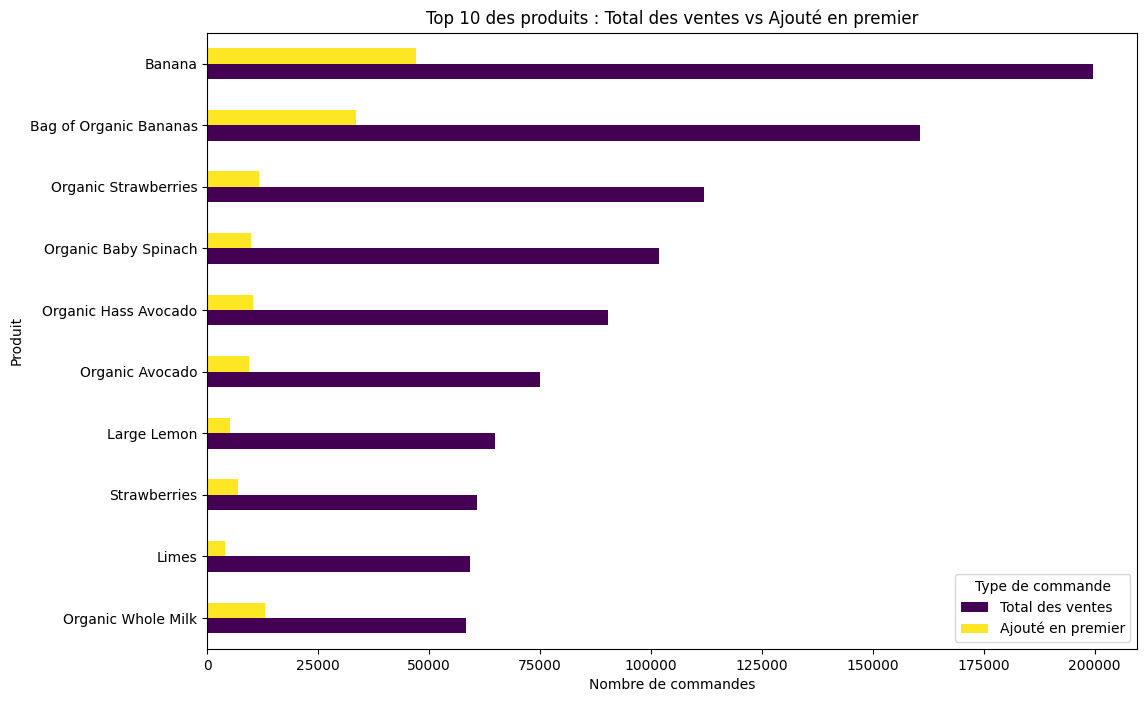

In [11]:
top_10_products = df['product_name'].value_counts().head(10)

first_in_cart = df[df['add_to_cart_order'] == 1.0]
first_in_cart_counts = first_in_cart[first_in_cart['product_name'].isin(top_10_products.index)]['product_name'].value_counts()

combined_data = pd.DataFrame({
    'Total des ventes': top_10_products,
    'Ajouté en premier': first_in_cart_counts
}).fillna(0)

combined_data = combined_data.sort_values(by='Total des ventes', ascending=True)

ax = combined_data.plot(kind='barh', figsize=(12, 8), color=['#440154', '#fde725'])

plt.title('Top 10 des produits : Total des ventes vs Ajouté en premier')
plt.xlabel('Nombre de commandes')
plt.ylabel('Produit')
plt.legend(title='Type de commande')
plt.show()

### 3. Distribution of orders by department
**Description:** This graph identifies the rays generating the largest flow of transactions among the Top 10 categories.

**Report & Business Insight:** The 'produce' section (33%) largely dominates, followed by 'dairy eggs' (18.8%). These two expense areas alone capture more than half of the activity. On the other hand, dry products and catering ("deli", "pasta") remain marginal (about 3%). This confirms that our platform is primarily popular for the supply of daily fresh products.

**Strategic action :** Use the massive flow from the 'produce' section as a cross-selling lever. By suggesting complementary products through recipe ideas (e.g. combining pasta or cheese with the purchase of vegetables), we can increase the average basket towards less popular categories.

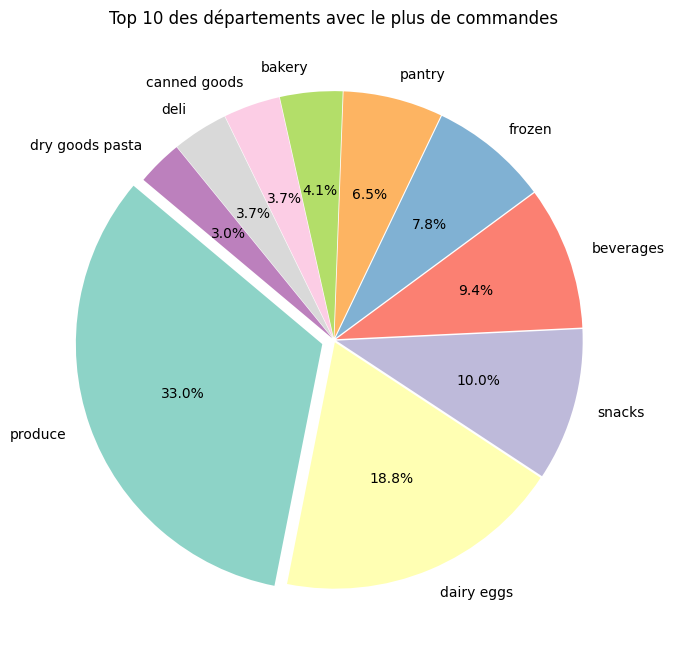

In [12]:
dept_counts = df['department'].value_counts().head(10)

plt.figure(figsize=(8, 8))
plt.pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%', startangle=140, explode=(0.05, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01), colors=sns.color_palette("Set3"))
plt.title('Top 10 des départements avec le plus de commandes')
plt.show()

### 4. Order profile: Average basket size
**Description:** Histogram showing the distribution of the number of items per order.

**Report & Business Insight:** The majority of baskets contain between 5 and 10 items. However, there is a long "tail" of customers who order more than 20 items (the big family buyers).

*Strategic action:* To encourage small baskets to grow, we can implement a recommendation system such as: "Customers who bought this item also bought..." or offer free shipping from a certain number of items (ex: 15 items).

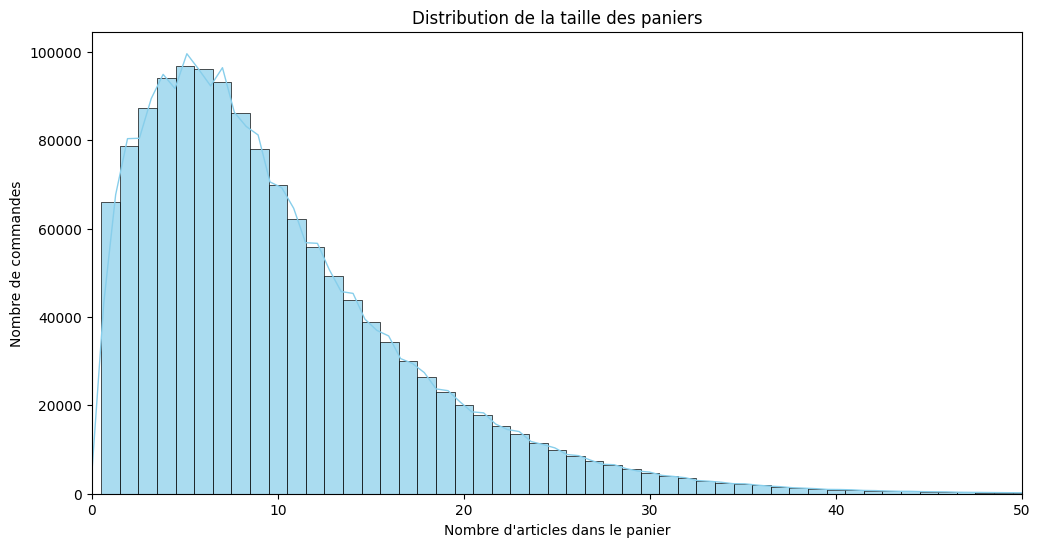

In [13]:
cart_sizes = df.groupby('order_id')['add_to_cart_order'].max()

plt.figure(figsize=(12, 6))
sns.histplot(cart_sizes, bins=50, kde=True, color='skyblue', edgecolor='black', alpha=0.7, stat='count', discrete=True, line_kws={'linewidth': 1}, fill=True)
plt.title('Distribution de la taille des paniers')
plt.xlabel("Nombre d'articles dans le panier")
plt.ylabel('Nombre de commandes')
plt.xlim(0, 50)
plt.show()

### 5. Is there a relationship between the time of the last order and the probability of recommending?
**Description :** Curve illustrating the frequency of re-order based on the number of days elapsed since the last purchase.

**Report & Business Insight:** We observe very clear peaks in re-orders at 7 days, 14 days, 21 days and 30 days. This demonstrates that our customers have cyclical buying habits, mainly weekly or monthly.

*Strategic action :* The marketing team should automate the sending of notifications (push or email) of the type "It’s time to refuel!" exactly on the 6th or 29th day after the client’s last order.

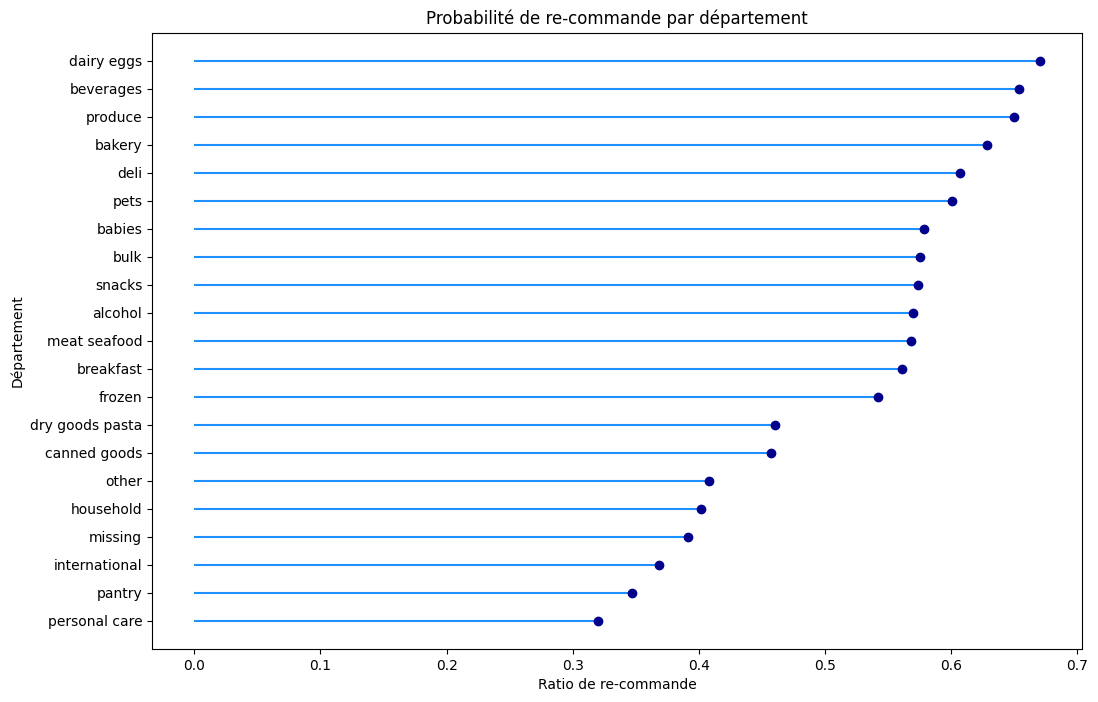

In [14]:
dept_reorder = df.groupby('department')['reordered'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
plt.hlines(y=dept_reorder.index, xmin=0, xmax=dept_reorder.values, color='dodgerblue')
plt.plot(dept_reorder.values, dept_reorder.index, "o", color='darkblue')
plt.title('Probabilité de re-commande par département')
plt.xlabel('Ratio de re-commande')
plt.ylabel('Département')
plt.show()

### 6. What is the proportion of organic food orders?
**Description:** Pie chart comparing the share of products containing the term "Organic" compared to the rest of the catalog.

**Report & Business Insight:** Organic products represent a very significant and growing part of our sales (usually around 30% of the total volume on this dataset). The clientele is very sensitive to quality and the organic label, particularly for fruits and vegetables.

*Strategic action :* Create a dedicated "100% Organic" section or a quick filter on the application. Increase margins or offer premium delivery subscriptions for this clientele ready to invest in healthy eating.

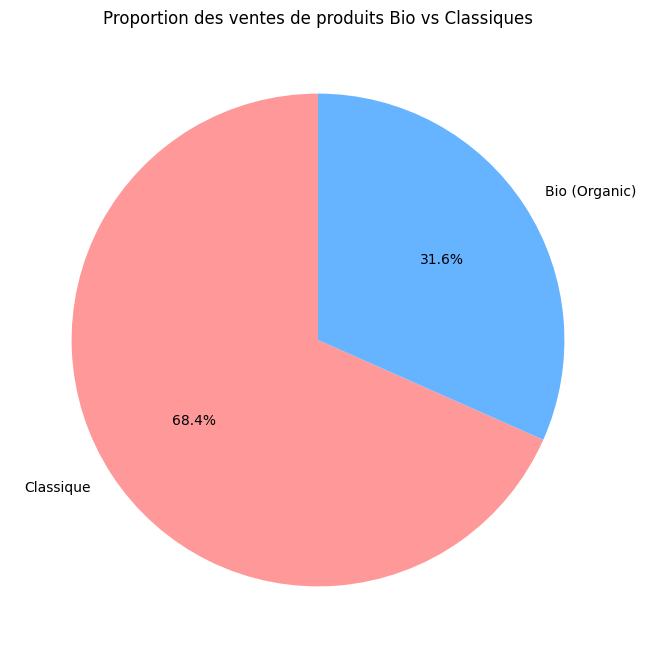

In [15]:
df['is_organic'] = df['product_name'].str.contains('Organic', case=False, na=False)
organic_counts = df['is_organic'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(organic_counts, labels=['Classique', 'Bio (Organic)'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Proportion des ventes de produits Bio vs Classiques')
plt.show()

### 7. Relationship analysis: Correlation matrix
**Description:** This heat map represents the coefficients of linear correlation between our different numerical variables. A score close to 1 (or -1) indicates a strong relationship, while a score close to 0 indicates no direct link.

**Report & Business Insight:** The main observation here is that the majority of our variables are independent (scores very close to 0). However, there is a slight negative correlation (-0.14) between `add_to_cart_order` and `reordered`. This teaches us a very interesting thing: the earlier an item is added to the cart (low figure), the more likely it is to be an item already ordered before by that customer (value 1). Customers therefore start their shopping with their usual 'must-haves'.

*Strategic action :* When creating our recommendation model (Machine Learning), the fact that a product has already been ordered will be a strong predictor for guessing what the client will put first in their next basket. We will be able to create a feature "Add my usual favorites in one click".

/tmp/ipykernel_1316/1702749397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aisles.values, y=top_aisles.index, palette="cubehelix")


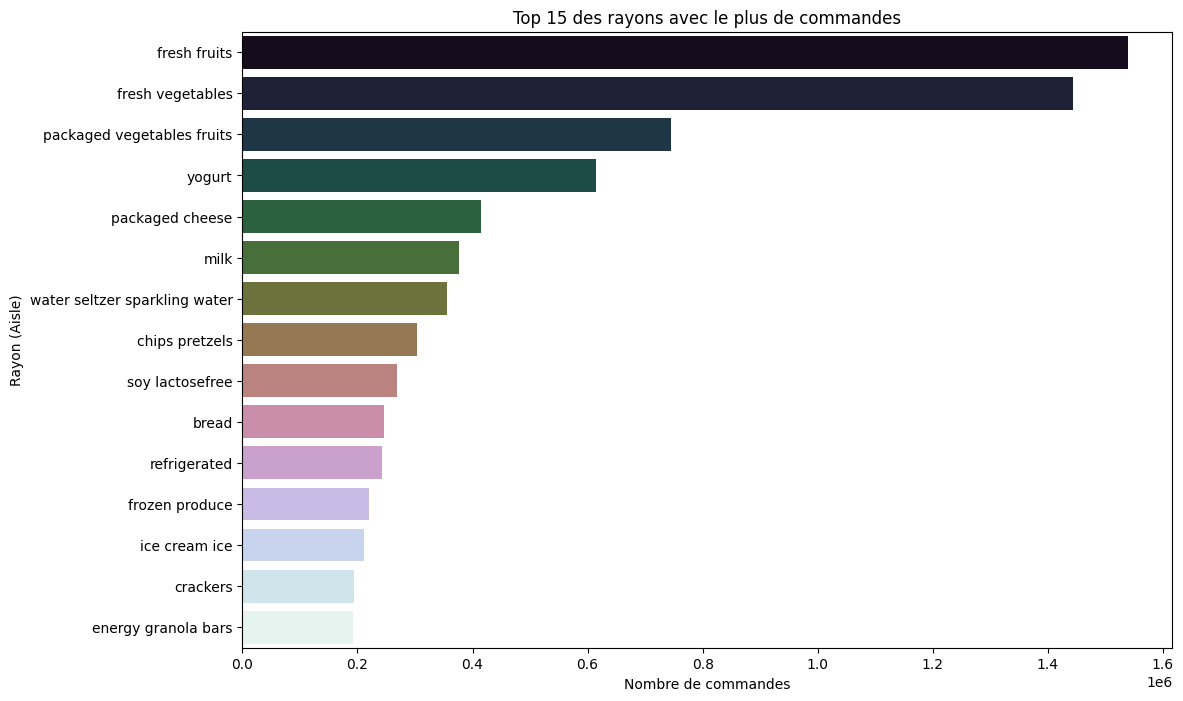

In [16]:
top_aisles = df['aisle'].value_counts().head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_aisles.values, y=top_aisles.index, palette="cubehelix")
plt.title('Top 15 des rayons avec le plus de commandes')
plt.xlabel('Nombre de commandes')
plt.ylabel('Rayon (Aisle)')
plt.show()